### 타이어 마모 정도

📡 1. 패킷 데이터 병합 중...

🔮 [Sleipnir Agent] 1랩 시작 기준, 3랩 학습 후 예측 실행 결과:
{
    "w_fl": {
        "start_lap": 1,
        "learned_until_lap": 4,
        "predicted_target_lap": 7,
        "wear_at_learning_end": 15.1,
        "predicted_wear": 30.19,
        "status": "danger"
    },
    "w_fr": {
        "start_lap": 1,
        "learned_until_lap": 4,
        "predicted_target_lap": 7,
        "wear_at_learning_end": 11.89,
        "predicted_wear": 23.79,
        "status": "Good"
    },
    "w_rl": {
        "start_lap": 1,
        "learned_until_lap": 4,
        "predicted_target_lap": 7,
        "wear_at_learning_end": 18.0,
        "predicted_wear": 36.0,
        "status": "danger"
    },
    "w_rr": {
        "start_lap": 1,
        "learned_until_lap": 4,
        "predicted_target_lap": 7,
        "wear_at_learning_end": 9.0,
        "predicted_wear": 17.99,
        "status": "Good"
    }
}


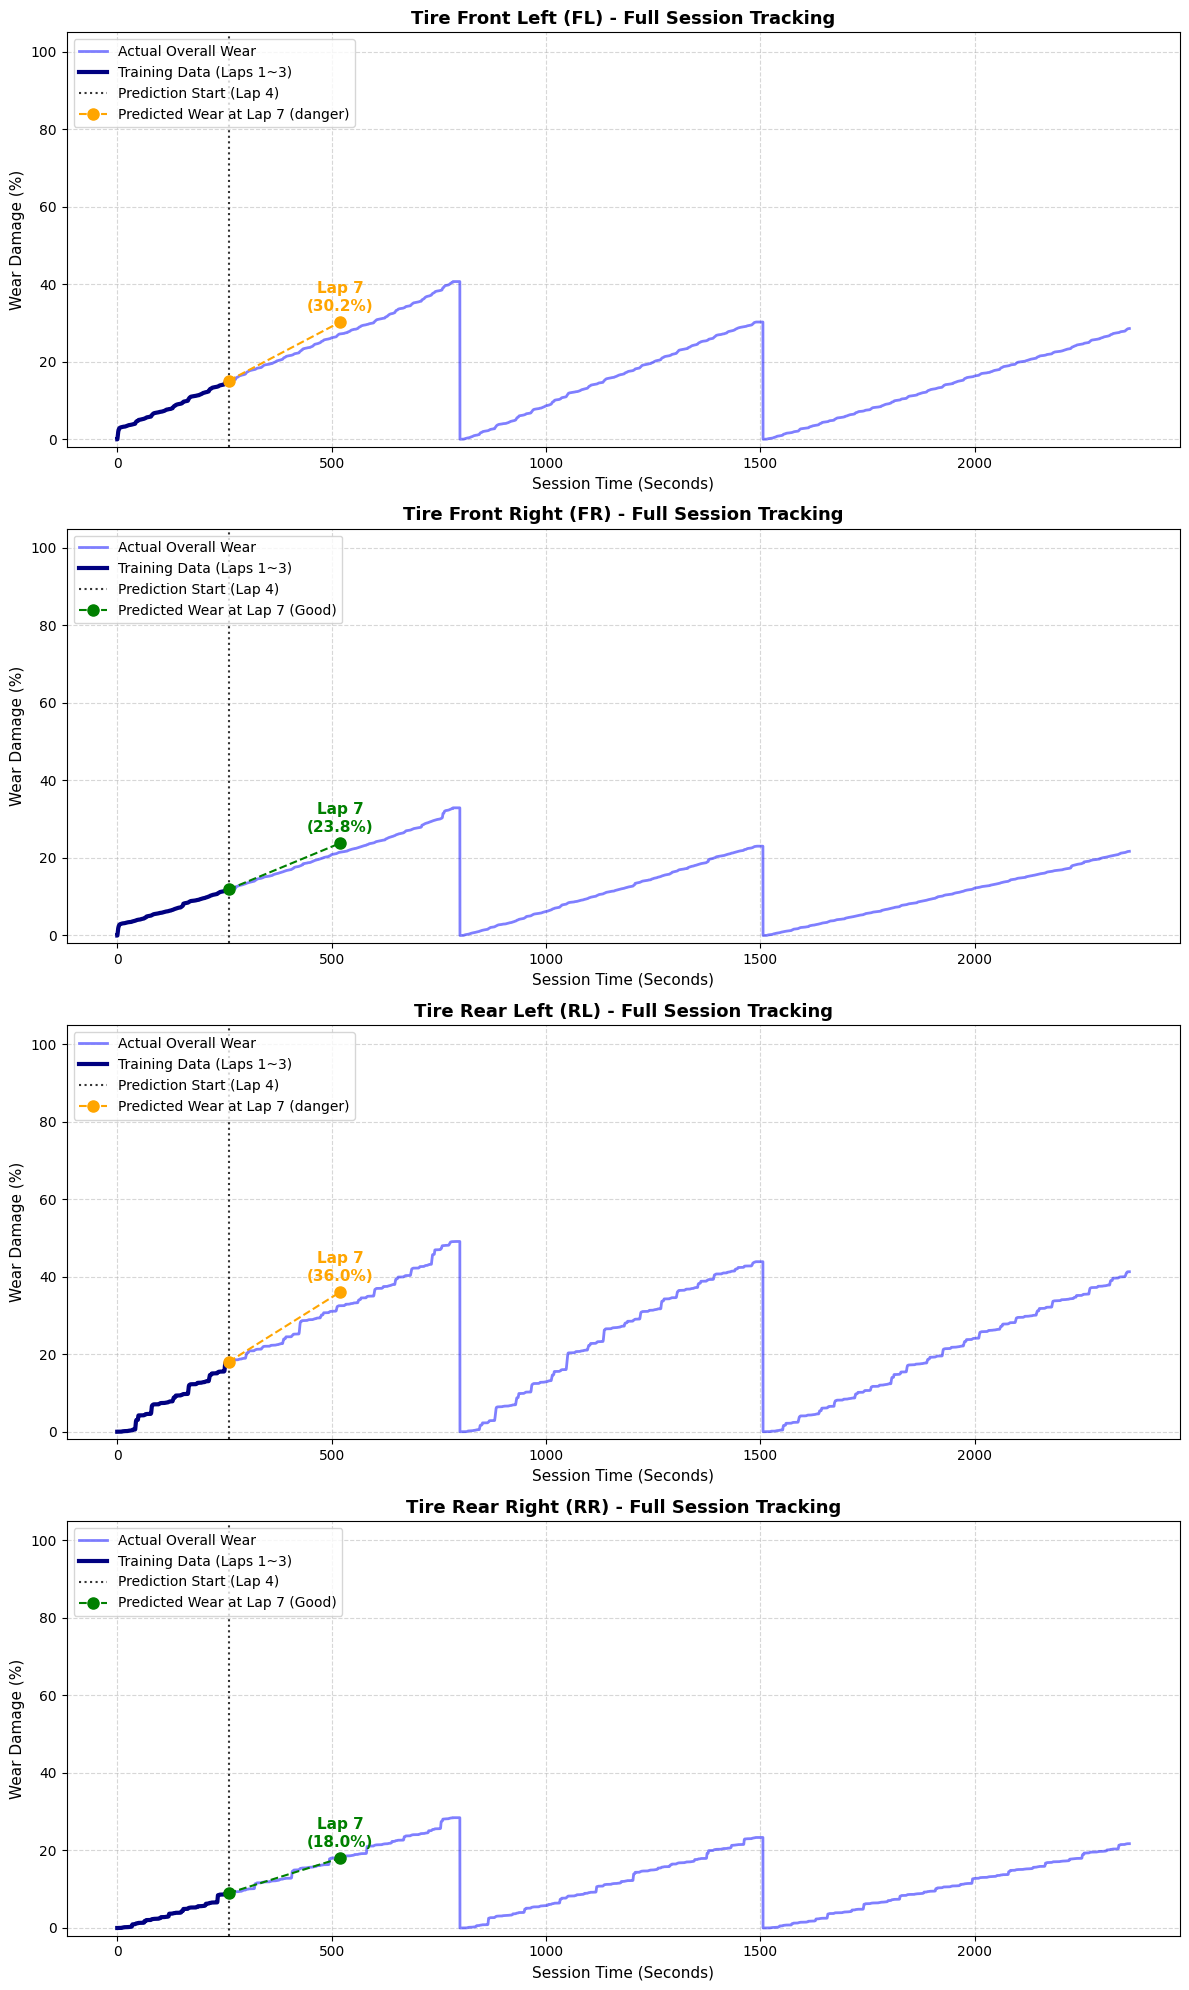

In [5]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_all_packets_with_laps(damage_file, tele_file, motion_file, lap_file):
    def flatten(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line)
                    idx = d['m_header']['m_playerCarIndex']
                    t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'damage':
                        w = d['m_carDamageData'][idx]['m_tyresWear']
                        row['w_fl'], row['w_fr'], row['w_rl'], row['w_rr'] = w[0], w[1], w[2], w[3]
                    elif p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['brake'], row['steer'], row['speed'] = data['m_brake'], data['m_steer'], data['m_speed']
                        tmp = data['m_tyresSurfaceTemperature']
                        row['t_fl'], row['t_fr'], row['t_rl'], row['t_rr'] = tmp[0], tmp[1], tmp[2], tmp[3]
                    elif p_type == 'motion':
                        m_data = d['m_carMotionData'][idx]
                        row['g_lat'], row['g_lon'], row['g_vert'] = abs(m_data['m_gForceLateral']), abs(m_data['m_gForceLongitudinal']), abs(m_data['m_gForceVertical'])
                    elif p_type == 'lap':
                        row['lap_num'] = d['m_lapData'][idx]['m_currentLapNum']
                    rows.append(row)
                except: 
                    continue
        return pd.DataFrame(rows).sort_values('time')

    print("📡 1. 패킷 데이터 병합 중...")
    df_d = flatten(damage_file, 'damage')
    df_t = flatten(tele_file, 'tele')
    df_m = flatten(motion_file, 'motion')
    df_l = flatten(lap_file, 'lap')
    
    combined = pd.merge_asof(df_d, df_t, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_m, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_l, on='time', direction='nearest').dropna()
    return combined

def predict_and_plot_tire_status(df, obs_laps=3, predict_ahead=3):
    wheels = ['fl', 'fr', 'rl', 'rr']
    wheel_names = ['Front Left', 'Front Right', 'Rear Left', 'Rear Right']
    features_base = ['speed', 'brake', 'steer', 'g_lat', 'g_lon', 'g_vert']
    
    # [수정됨] 스틴트를 자르지 않고 전체 세션 데이터를 그대로 사용합니다.
    session_data = df.copy().reset_index(drop=True)
    
    if len(session_data) < 100:
        print(json.dumps({"error": "전체 데이터가 너무 부족합니다."}, ensure_ascii=False))
        return
        
    # 데이터셋의 진짜 첫 번째 랩 번호를 가져옵니다. (정상적이라면 1랩)
    start_lap = int(session_data['lap_num'].min())
    
    # 시작 랩(예: 1랩)부터 지정한 랩(예: +3랩)까지만 학습(관찰) 데이터로 분리
    obs_mask = session_data['lap_num'] < (start_lap + obs_laps)
    obs_set = session_data[obs_mask].copy()
    
    if obs_set.empty:
        print(json.dumps({"error": "초기 3랩 관찰 데이터가 존재하지 않습니다."}, ensure_ascii=False))
        return

    # 시간축 동기화를 위한 기준 시간
    session_start_time = session_data['time'].iloc[0]
    obs_end_time = obs_set['time'].iloc[-1]
    
    # 랩당 평균 소요 시간 (물리적 시간 예측용)
    avg_time_per_lap = (obs_end_time - session_start_time) / obs_laps
    target_future_time = obs_end_time + (avg_time_per_lap * predict_ahead)

    fig, axes = plt.subplots(4, 1, figsize=(12, 20))
    result = {}
    
    for i, w in enumerate(wheels):
        target_col = f'w_{w}'
        wheel_features = features_base + [f't_{w}']
        
        # 선형 회귀 모델 학습 (1~3랩 기준)
        obs_set['delta_w'] = obs_set[target_col].diff().fillna(0)
        model = LinearRegression()
        model.fit(obs_set[wheel_features], obs_set['delta_w'])
        
        # 1랩당 예상 마모 변화량 연산
        mean_features = obs_set[wheel_features].mean().to_frame().T
        pred_delta_per_packet = max(0, model.predict(mean_features)[0])
        packets_per_lap = len(obs_set) / obs_laps
        estimated_wear_per_lap = pred_delta_per_packet * packets_per_lap
        
        # 3랩 종료 시점의 실제 마모도
        current_actual_wear = obs_set[target_col].iloc[-1]
        
        # 3랩 뒤의 예측 마모도 (현재 마모도 + (1랩 예상 마모량 * 3랩))
        predicted_wear = current_actual_wear + (estimated_wear_per_lap * predict_ahead)
        predicted_wear = min(100.0, max(current_actual_wear, predicted_wear))
        
        # 상태 판정 (0~30: 양호, 31~60: 중간, 61~: 위험)
        if predicted_wear <= 30:
            status, color_zone = "Good", "green"
        elif predicted_wear <= 60:
            status, color_zone = "danger", "orange"
        else:
            status, color_zone = "danger", "red"
            
        result[f"w_{w}"] = {
            "start_lap": start_lap,
            "learned_until_lap": start_lap + obs_laps,
            "predicted_target_lap": start_lap + obs_laps + predict_ahead,
            "wear_at_learning_end": round(float(current_actual_wear), 2),
            "predicted_wear": round(float(predicted_wear), 2),
            "status": status
        }
        
        # --- 📊 전체 랩 시각화 ---
        ax = axes[i]
        
        # 1. 전체 세션 실제 데이터 출력 (1랩부터 끝까지 전부)
        ax.plot(session_data['time'], session_data[target_col], label='Actual Overall Wear', color='blue', alpha=0.5, linewidth=2)
        
        # 2. 관찰(학습) 구간 강조 (예: 1랩~3랩 구간)
        ax.plot(obs_set['time'], obs_set[target_col], color='navy', linewidth=3, label=f'Training Data (Laps {start_lap}~{start_lap+obs_laps-1})')
        
        # 3. 예측 시작점 가이드선 (3랩 종료 시점)
        ax.axvline(x=obs_end_time, color='black', linestyle=':', alpha=0.8, label=f'Prediction Start (Lap {start_lap + obs_laps})')
        
        # 4. 미래 예측선 (3랩 종료 시점 -> 6랩 예측 시점)
        ax.plot([obs_end_time, target_future_time], [current_actual_wear, predicted_wear], 
                color=color_zone, linestyle='--', marker='o', markersize=8,
                label=f'Predicted Wear at Lap {start_lap + obs_laps + predict_ahead} ({status})')
        
        # 텍스트 정보 표시
        ax.text(target_future_time, predicted_wear + 3, f"Lap {start_lap + obs_laps + predict_ahead}\n({predicted_wear:.1f}%)", 
                color=color_zone, weight='bold', fontsize=11, ha='center')
        
        # 스타일 및 라벨 세팅
        ax.set_title(f"Tire {wheel_names[i]} ({w.upper()}) - Full Session Tracking", fontsize=13, weight='bold')
        ax.set_ylabel("Wear Damage (%)", fontsize=11)
        ax.set_xlabel("Session Time (Seconds)", fontsize=11)
        ax.set_ylim(-2, 105)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper left')

    # 결과 JSON 출력
    print(json.dumps(result, ensure_ascii=False, indent=4))
    
    plt.tight_layout()
    plt.show()

# --- 실행부 ---
if __name__ == "__main__":
    damage_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl'
    telemetry_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_telemetry.jsonl'
    motion_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_motion.jsonl'
    lap_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_lap.jsonl'
    
    combined_v9 = load_all_packets_with_laps(damage_path, telemetry_path, motion_path, lap_path)
    
    print("\n🔮 [Sleipnir Agent] 1랩 시작 기준, 3랩 학습 후 예측 실행 결과:")
    predict_and_plot_tire_status(combined_v9, obs_laps=3, predict_ahead=3)

📡 1. 랩 데이터를 포함한 모든 패킷 병합 중...


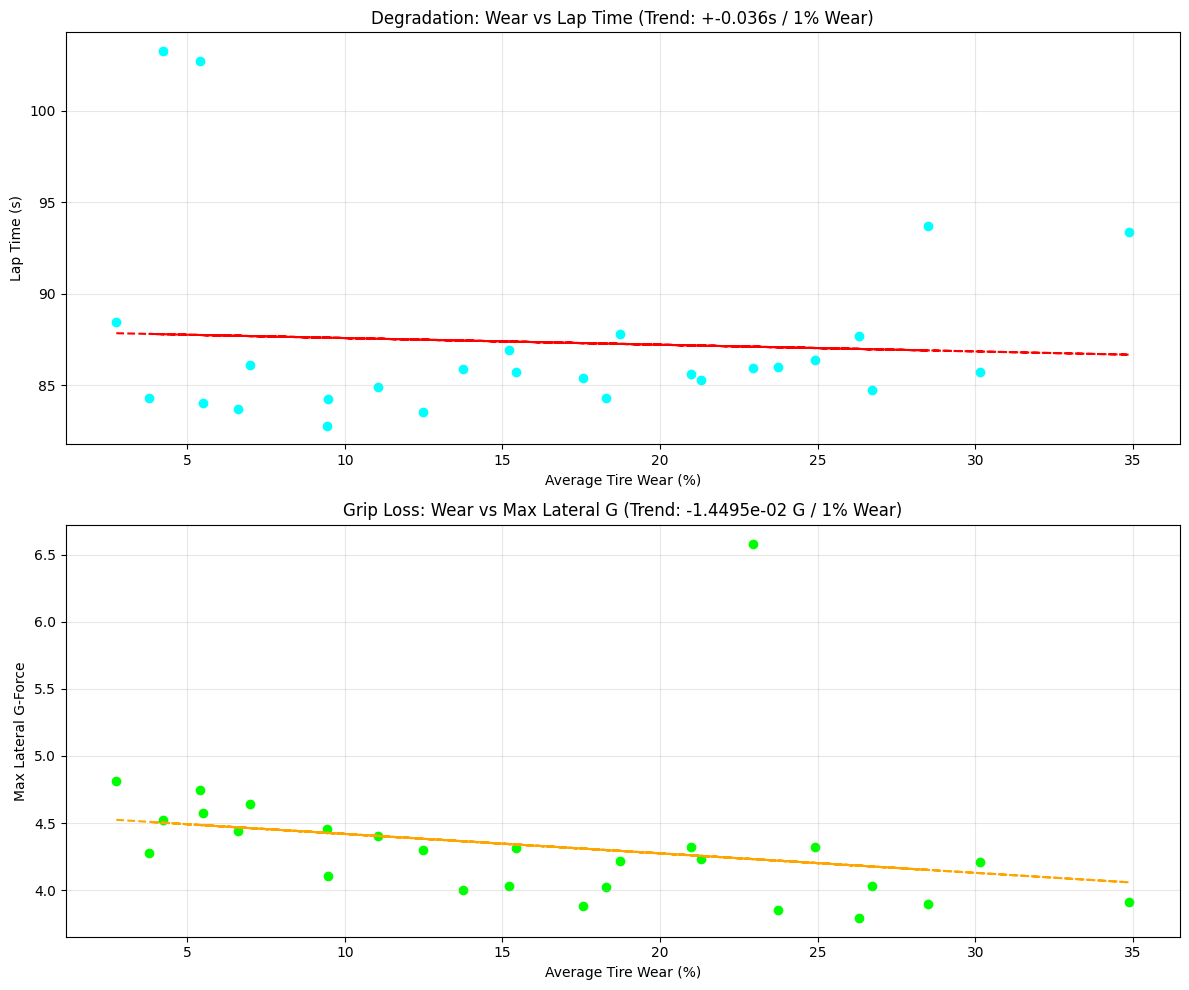


[Sleipnir v10 Analysis Result]
>>> 타이어가 1% 마모될 때마다 랩타임은 약 -0.0365초 느려집니다.
>>> 타이어가 1% 마모될 때마다 최대 그립력(G)은 약 0.0145만큼 감소합니다.


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def load_integrated_data(damage_file, tele_file, motion_file, lap_file):
    # [기존 flatten 로직과 동일하게 데이터 로드]
    # (코드 중략: 이전 load_all_packets_with_laps 함수와 동일)
    combined = load_all_packets_with_laps(damage_file, tele_file, motion_file, lap_file)
    return combined

def run_performance_deg_analysis(df):
    """
    마모도와 성능(G-Force, Lap Time) 사이의 상관관계를 분석합니다.
    """
    # 1. 랩 단위 데이터 요약
    # 각 랩에서의 평균 마모도, 최대 횡G, 랩타임을 추출합니다.
    lap_stats = []
    for lap_num, group in df.groupby('lap_num'):
        if len(group) < 50: continue # 불완전한 데이터 제외
        
        avg_wear = group[['w_fl', 'w_fr', 'w_rl', 'w_rr']].mean().mean()
        max_g = group['g_lat'].max()
        lap_time = group['time'].max() - group['time'].min()
        
        lap_stats.append({
            'lap_num': lap_num,
            'avg_wear': avg_wear,
            'max_g': max_g,
            'lap_time': lap_time
        })
    
    summary_df = pd.DataFrame(lap_stats)
    
    # 2. 성능 저하 상관관계 모델링
    # 마모도(X)에 따른 랩타임 증가(y) 선형 회귀
    model_time = LinearRegression()
    X_wear = summary_df[['avg_wear']]
    model_time.fit(X_wear, summary_df['lap_time'])
    deg_rate_time = model_time.coef_[0]
    
    # 마모도(X)에 따른 최대 그립력(y) 감소 선형 회귀
    model_g = LinearRegression()
    model_g.fit(X_wear, summary_df['max_g'])
    deg_rate_g = model_g.coef_[0]

    # 3. 결과 시각화
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # (1) Wear vs Lap Time
    ax1.scatter(summary_df['avg_wear'], summary_df['lap_time'], color='cyan', label='Data Points')
    ax1.plot(summary_df['avg_wear'], model_time.predict(X_wear), color='red', linestyle='--')
    ax1.set_title(f"Degradation: Wear vs Lap Time (Trend: +{deg_rate_time:.3f}s / 1% Wear)")
    ax1.set_xlabel("Average Tire Wear (%)")
    ax1.set_ylabel("Lap Time (s)")
    ax1.grid(alpha=0.3)

    # (2) Wear vs Max G-Force (Grip)
    ax2.scatter(summary_df['avg_wear'], summary_df['max_g'], color='lime', label='Data Points')
    ax2.plot(summary_df['avg_wear'], model_g.predict(X_wear), color='orange', linestyle='--')
    ax2.set_title(f"Grip Loss: Wear vs Max Lateral G (Trend: {deg_rate_g:.4e} G / 1% Wear)")
    ax2.set_xlabel("Average Tire Wear (%)")
    ax2.set_ylabel("Max Lateral G-Force")
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return deg_rate_time, deg_rate_g

# --- 실행부 ---
# 경로 설정 (사용자 경로에 맞춰 수정)
path_base = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza'
combined_v10 = load_all_packets_with_laps(
    f"{path_base}\\record_damage.jsonl",
    f"{path_base}\\record_telemetry.jsonl",
    f"{path_base}\\record_motion.jsonl",
    f"{path_base}\\record_lap.jsonl"
)

time_deg, grip_deg = run_performance_deg_analysis(combined_v10)

print(f"\n[Sleipnir v10 Analysis Result]")
print(f">>> 타이어가 1% 마모될 때마다 랩타임은 약 {time_deg:.4f}초 느려집니다.")
print(f">>> 타이어가 1% 마모될 때마다 최대 그립력(G)은 약 {abs(grip_deg):.4f}만큼 감소합니다.")

### 연료 소모량 예측

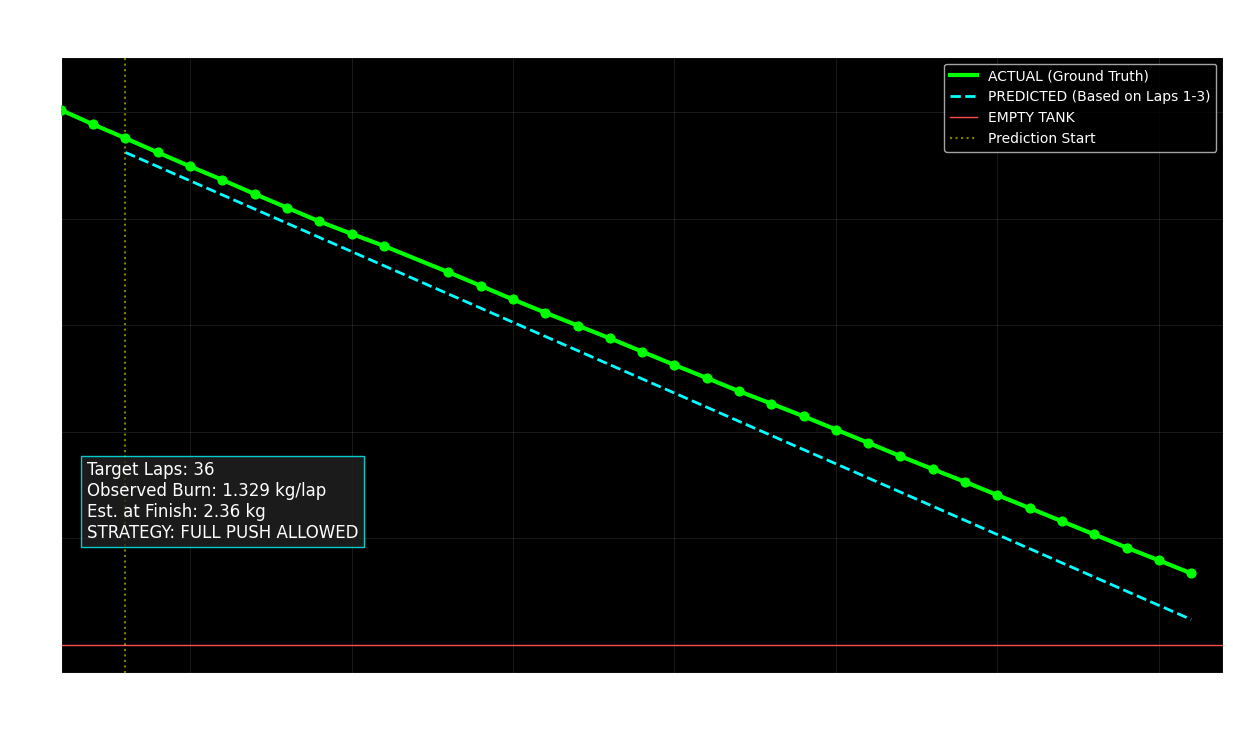

In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def get_total_laps(session_file):
    """record_session.jsonl 파일에서 총 레이스 랩수를 자동으로 추출합니다."""
    try:
        with open(session_file, 'r', encoding='utf-8') as f:
            for line in f:
                d = json.loads(line)
                # Packet ID 1: PacketSessionData
                if d['m_header']['m_packetId'] == 1:
                    total_laps = d.get('m_totalLaps', 0)
                    if total_laps > 0:
                        return total_laps
    except Exception as e:
        print(f"세션 파일 읽기 실패: {e}")
    
    return 53

def generate_sleipnir_v12_2_strategy(tele_file, status_file, lap_file, session_file):
    # 1. 총 랩수 자동 획득
    total_laps = get_total_laps(session_file)

    def load_packet_data(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line)
                    idx = d['m_header']['m_playerCarIndex']
                    t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    if p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['throttle'], row['rpm'] = data['m_throttle'], data['m_engineRPM']
                    elif p_type == 'status':
                        data = d['m_carStatusData'][idx]
                        row['fuel_in_tank'] = data['m_fuelInTank']
                    elif p_type == 'lap':
                        data = d['m_lapData'][idx]
                        row['lap_num'] = data['m_currentLapNum']
                    rows.append(row)
                except: continue
        return pd.DataFrame(rows).sort_values('time')

    # 2. 데이터 로드 및 병합
    df_t = load_packet_data(tele_file, 'tele')
    df_s = load_packet_data(status_file, 'status')
    df_l = load_packet_data(lap_file, 'lap')
    
    combined = pd.merge_asof(df_t, df_s, on='time', direction='nearest')
    combined = pd.merge_asof(combined, df_l, on='time', direction='nearest').dropna()

    # 3. 실제 전체 데이터 요약 (실선용)
    actual_lap_data = combined.groupby('lap_num')['fuel_in_tank'].first()

    # 4. 첫 3랩 기반 예측 로직 (점선용)
    all_laps = sorted(combined['lap_num'].unique())
    obs_laps = all_laps[:3]
    df_obs = combined[combined['lap_num'].isin(obs_laps)]
    
    # 3랩간의 평균 소모량 계산
    fuel_start = df_obs.groupby('lap_num')['fuel_in_tank'].first()
    avg_burn = fuel_start.diff().abs().mean()
    
    if pd.isna(avg_burn): # 데이터 부족 시 보정
        avg_burn = (df_obs['fuel_in_tank'].iloc[0] - df_obs['fuel_in_tank'].iloc[-1]) / len(obs_laps)

    # 5. 예측 데이터 생성 (3랩 끝점부터 총 랩수까지)
    last_obs_lap = obs_laps[-1]
    last_obs_fuel = df_obs['fuel_in_tank'].iloc[-1]
    
    future_x = np.arange(last_obs_lap, total_laps + 1)
    future_y = last_obs_fuel - (avg_burn * (future_x - last_obs_lap))
    
    # 엔진 정지 시점 계산
    death_lap = last_obs_lap + (last_obs_fuel / avg_burn)

    # 6. 시각화
    plt.figure(figsize=(15, 8))
    plt.style.use('dark_background')

    # [실제 데이터] 전체 주행 구간 - 굵은 초록색 실선
    plt.plot(actual_lap_data.index, actual_lap_data.values, 
             color='#00ff00', linewidth=3, label='ACTUAL (Ground Truth)', zorder=10)
    plt.scatter(actual_lap_data.index, actual_lap_data.values, color='#00ff00', s=40, zorder=11)

    # [예측 데이터] 3랩 이후 구간 - 하늘색 점선
    plt.plot(future_x, future_y, 
             color='#00ffff', linestyle='--', linewidth=2, label=f'PREDICTED (Based on Laps {obs_laps[0]}-{obs_laps[-1]})', zorder=5)

    # 기준선 및 강조
    plt.axhline(0, color='#ff4d4d', linestyle='-', linewidth=1, label='EMPTY TANK')
    plt.axvline(last_obs_lap, color='yellow', linestyle=':', alpha=0.5, label='Prediction Start')

    # 엔진 정지 표기
    if death_lap <= total_laps:
        plt.scatter(death_lap, 0, color='red', s=150, marker='X', zorder=20)
        plt.annotate(f'STALL AT LAP {death_lap:.1f}', (death_lap, 2), color='red', weight='bold', ha='center')

    # 그래프 서식
    plt.title(f'Sleipnir v12.2: Fuel Strategy Accuracy Analysis', fontsize=18, pad=20)
    plt.xlabel('Lap Number', fontsize=12)
    plt.ylabel('Fuel in Tank (kg)', fontsize=12)
    plt.ylim(min(future_y.min(), actual_lap_data.min()) - 5, actual_lap_data.max() + 5)
    plt.xlim(1, total_laps + 1)
    plt.grid(True, alpha=0.1)
    plt.legend(loc='upper right')

    # 전략 리포트 텍스트
    finish_fuel = future_y[-1]
    status = "LIFT & COAST REQUIRED" if finish_fuel < 0 else "FULL PUSH ALLOWED"
    report = (f"Target Laps: {total_laps}\n"
              f"Observed Burn: {avg_burn:.3f} kg/lap\n"
              f"Est. at Finish: {finish_fuel:.2f} kg\n"
              f"STRATEGY: {status}")
    
    plt.text(total_laps*0.05, actual_lap_data.max()*0.2, report, fontsize=12, 
             color='white', bbox=dict(facecolor='#222222', alpha=0.8, edgecolor='cyan'))

    plt.show()

# --- 실행부 ---
path_base = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\Zandvoort'
generate_sleipnir_v12_2_strategy(
    f"{path_base}\\record_telemetry.jsonl",
    f"{path_base}\\record_status.jsonl",
    f"{path_base}\\record_lap.jsonl",
    f"{path_base}\\record_session.jsonl" # 세션 파일 추가
)

### 엔진 데미지 예측

📡 데이터 파싱 및 병합 중...


d:\code\Collection_of_virtual\SLM_space\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\code\Collection_of_virtual\SLM_space\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\code\Collection_of_virtual\SLM_space\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\code\Collection_of_virtual\SLM_space\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\code\Collection_of_virtual\SLM_space\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegressi

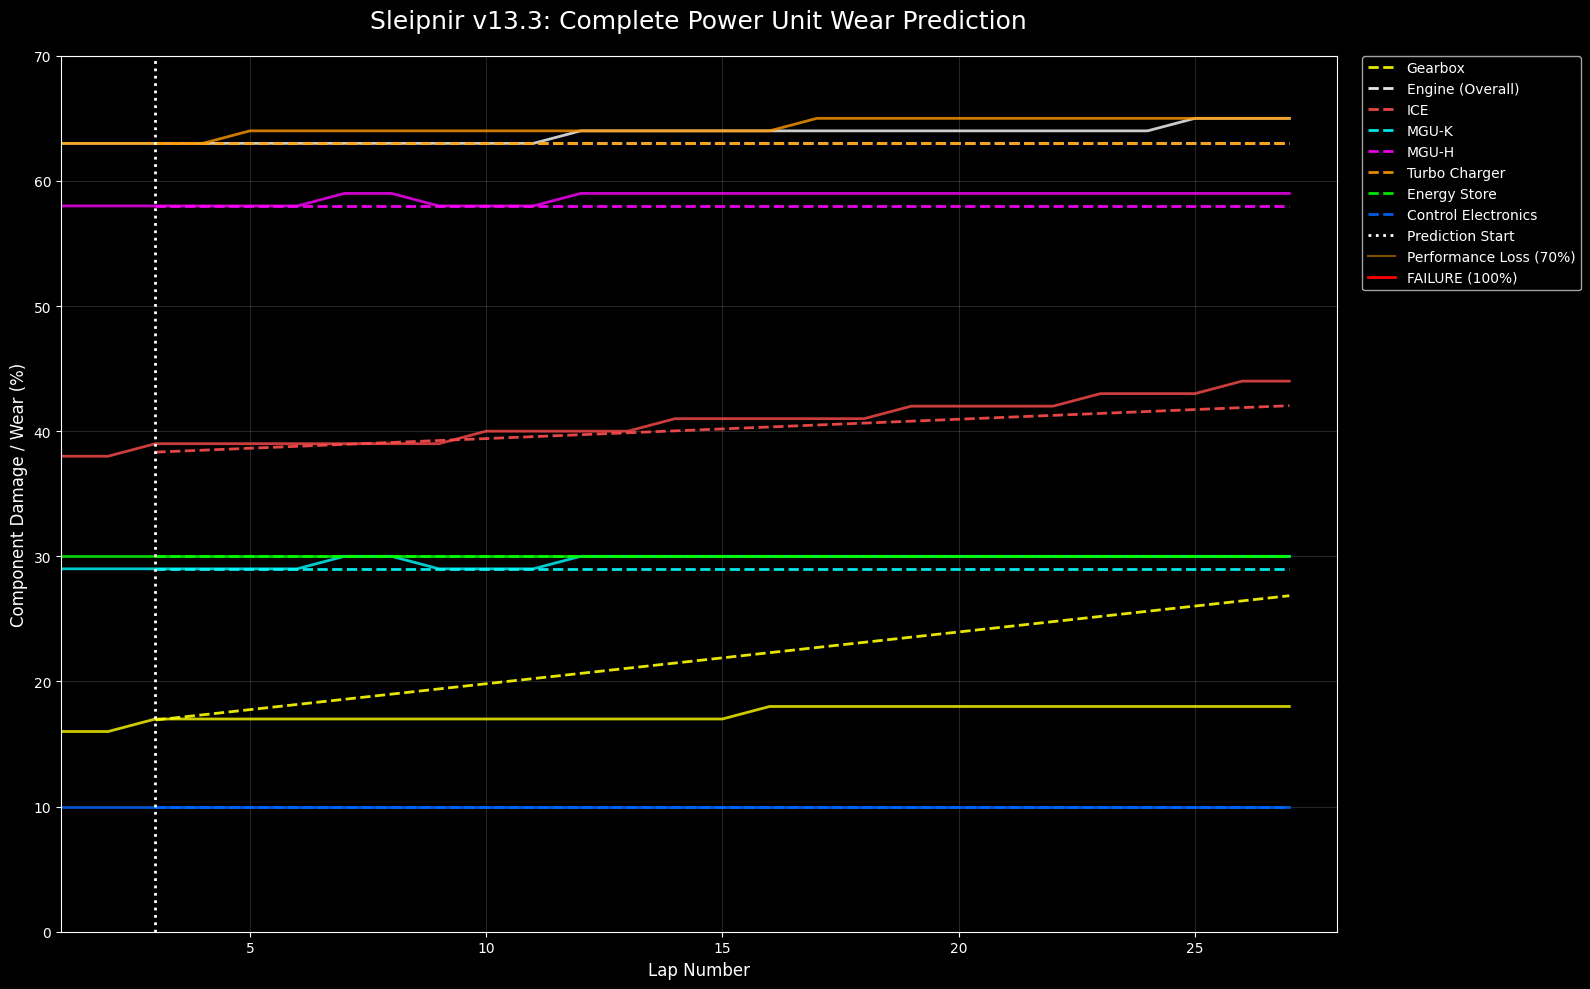

In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def generate_sleipnir_v13_3_integral_model(tele_file, damage_file, lap_file, session_file):
    # 1. 총 랩수 파싱
    total_laps = 53
    try:
        with open(session_file, 'r', encoding='utf-8') as f:
            for line in f:
                d = json.loads(line)
                if d['m_header']['m_packetId'] == 1 and d.get('m_totalLaps', 0) > 0:
                    total_laps = d['m_totalLaps']
                    break
    except: pass

    # 2. 데이터 병합 및 전체 부품 추출
    def load_packet_data(path, p_type):
        rows = []
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                try:
                    d = json.loads(line)
                    idx = d['m_header']['m_playerCarIndex']
                    t = d['m_header']['m_sessionTime']
                    row = {'time': t}
                    
                    if p_type == 'tele':
                        data = d['m_carTelemetryData'][idx]
                        row['throttle'] = data['m_throttle']
                        row['brake'] = data['m_brake']
                        row['rpm'] = data['m_engineRPM']
                        row['temp'] = data['m_engineTemperature']
                        row['gear'] = data['m_gear']
                        
                    elif p_type == 'damage':
                        data = d['m_carDamageData'][idx]
                        row['gearbox_damage'] = data.get('m_gearBoxDamage', 0)
                        row['engine_damage'] = data.get('m_engineDamage', 0)
                        row['ice_wear'] = data.get('m_engineICEWear', 0)
                        row['mguk_wear'] = data.get('m_engineMGUKWear', 0)
                        row['mguh_wear'] = data.get('m_engineMGUHWear', 0)
                        row['tc_wear'] = data.get('m_engineTCWear', 0)
                        row['es_wear'] = data.get('m_engineESWear', 0)
                        row['ce_wear'] = data.get('m_engineCEWear', 0)
                        
                    elif p_type == 'lap':
                        row['lap_num'] = d['m_lapData'][idx]['m_currentLapNum']
                    rows.append(row)
                except: continue
        
        df = pd.DataFrame(rows)
        return df.sort_values('time')

    print("📡 데이터 파싱 및 병합 중...")
    df_t = load_packet_data(tele_file, 'tele')
    df_d = load_packet_data(damage_file, 'damage')
    df_l = load_packet_data(lap_file, 'lap')
    
    df = pd.merge_asof(df_t, df_d, on='time', direction='nearest')
    df = pd.merge_asof(df, df_l, on='time', direction='nearest').dropna()

    # 3. 순간 스트레스 계산
    df['shift_shock'] = (df['gear'].diff().abs() > 0).astype(int)
    
    df['gear_stress_inst'] = df['shift_shock'] * (df['rpm'] / 10000)
    df['ice_stress_inst'] = df['throttle'] * (df['rpm'] / 10000) * (df['temp'] / 100)
    df['mguk_stress_inst'] = df['brake'] + df['throttle']
    df['mguh_stress_inst'] = df['throttle'] * (df['rpm'] / 10000)
    df['tc_stress_inst'] = df['throttle'] * (df['rpm'] / 10000)**2
    df['es_stress_inst'] = (df['brake'] * 1.5) + df['throttle']
    df['ce_stress_inst'] = df['rpm'] / 10000

    # 타겟 부품과 해당 스트레스 매핑 딕셔너리
    components_map = {
        'gearbox_damage': ('Gearbox', 'gear_stress_inst', '#ffff00'),
        'engine_damage': ('Engine (Overall)', 'ice_stress_inst', '#ffffff'),
        'ice_wear': ('ICE', 'ice_stress_inst', '#ff4d4d'),
        'mguk_wear': ('MGU-K', 'mguk_stress_inst', '#00ffff'),
        'mguh_wear': ('MGU-H', 'mguh_stress_inst', '#ff00ff'),
        'tc_wear': ('Turbo Charger', 'tc_stress_inst', '#ff9900'),
        'es_wear': ('Energy Store', 'es_stress_inst', '#00ff00'),
        'ce_wear': ('Control Electronics', 'ce_stress_inst', '#0066ff')
    }

    # 누적 스트레스(적분) 적용
    for target, (name, stress_col, color) in components_map.items():
        df[f'{stress_col}_cum'] = df[stress_col].cumsum()

    # 4. 모델 학습 (1~3랩 기준)
    all_laps = sorted(df['lap_num'].unique())
    obs_laps = all_laps[:3]
    df_obs = df[df['lap_num'].isin(obs_laps)].copy()
    last_obs_lap = obs_laps[-1]
    future_x_laps = np.arange(last_obs_lap, total_laps + 1)

    predictions = {}
    
    for target, (name, stress_col, color) in components_map.items():
        cum_col = f'{stress_col}_cum'
        
        # 선형 회귀 학습
        model = LinearRegression()
        model.fit(df_obs[[cum_col]], df_obs[target])
        
        # 1랩당 평균 스트레스 적분량 산출
        stress_per_lap = (df_obs[cum_col].iloc[-1] - df_obs[cum_col].iloc[0]) / len(obs_laps)
        
        # 미래 누적 스트레스 투사 및 예측
        future_stress = df_obs[cum_col].iloc[-1] + (stress_per_lap * (future_x_laps - last_obs_lap))
        pred_wear = model.predict(future_stress.reshape(-1, 1))
        
        predictions[target] = pred_wear

    # 5. 시각화
    actual_lap_data = df.groupby('lap_num').last()
    actual_x = actual_lap_data.index

    plt.figure(figsize=(16, 10))
    plt.style.use('dark_background')

    for target, (name, stress_col, color) in components_map.items():
        # 실제 데이터 플롯
        plt.plot(actual_x, actual_lap_data[target], color=color, linewidth=2, alpha=0.8)
        # 예측 데이터 플롯
        plt.plot(future_x_laps, predictions[target], color=color, linestyle='--', linewidth=2, alpha=0.9, label=name)

    plt.axvline(last_obs_lap, color='white', linestyle=':', linewidth=2, label='Prediction Start')
    plt.axhline(70, color='orange', linestyle='-', alpha=0.5, label='Performance Loss (70%)')
    plt.axhline(100, color='red', linestyle='-', linewidth=2, label='FAILURE (100%)')

    plt.title('Sleipnir v13.3: Complete Power Unit Wear Prediction', fontsize=18, pad=20)
    plt.xlabel('Lap Number', fontsize=12)
    plt.ylabel('Component Damage / Wear (%)', fontsize=12)
    
    # Y축 최대값 동적 조정
    max_pred = max([pred[-1] for pred in predictions.values()])
    max_actual = actual_lap_data[list(components_map.keys())].max().max()
    plt.ylim(0, min(105, max(max_pred, max_actual) + 5))
    plt.xlim(1, total_laps + 1)
    
    plt.grid(True, alpha=0.15)
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), prop={'size': 10}, borderaxespad=0.)
    plt.tight_layout()
    plt.show()

# --- 실행 ---
base_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza'
generate_sleipnir_v13_3_integral_model(
    f"{base_path}\\record_telemetry.jsonl",
    f"{base_path}\\record_damage.jsonl",
    f"{base_path}\\record_lap.jsonl",
    f"{base_path}\\record_session.jsonl"
)

In [8]:
import json
import pandas as pd

def get_current_pu_status_json(damage_file):
    """
    가장 최근의 Car Damage 패킷을 분석하여, 
    LM(Language Model)에게 전달할 현재 파워 유닛 및 기어박스 상태를 JSON으로 반환합니다.
    """
    latest_row = None
    
    # 패킷을 순차적으로 읽어 가장 마지막(최신) 데이터만 추출
    with open(damage_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                idx = d['m_header']['m_playerCarIndex']
                data = d['m_carDamageData'][idx]
                
                latest_row = {
                    'Gearbox': data.get('m_gearBoxDamage', 0),
                    'ICE': data.get('m_engineICEWear', 0),
                    'MGU-K': data.get('m_engineMGUKWear', 0),
                    'MGU-H': data.get('m_engineMGUHWear', 0),
                    'TC': data.get('m_engineTCWear', 0),
                    'ES': data.get('m_engineESWear', 0),
                    'CE': data.get('m_engineCEWear', 0),
                    'Engine_Overall': data.get('m_engineDamage', 0)
                }
            except:
                continue

    if not latest_row:
        return json.dumps({"error": "데미지 패킷을 불러올 수 없습니다."}, ensure_ascii=False)

    # LM이 상황을 이해하기 쉽도록 상태(Status) 텍스트 부여 로직
    def get_status_text(wear_percent):
        if wear_percent >= 70:
            return "위험 (성능 저하 및 리타이어 가능성)"
        elif wear_percent >= 50:
            return "주의 (마모 진행 중, 관리 필요)"
        else:
            return "양호"

    result = {"power_unit_status": {}}
    
    for component, wear in latest_row.items():
        result["power_unit_status"][component] = {
            "wear_percent": wear,
            "status": get_status_text(wear)
        }

    return json.dumps(result, ensure_ascii=False, indent=4)

# --- 실행부 ---
damage_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza\record_damage.jsonl'
lm_context_json = get_current_pu_status_json(damage_path)

print("📡 [Sleipnir Agent] LM 전달용 파워 유닛 현재 상태:")
print(lm_context_json)

📡 [Sleipnir Agent] LM 전달용 파워 유닛 현재 상태:
{
    "power_unit_status": {
        "Gearbox": {
            "wear_percent": 18,
            "status": "양호"
        },
        "ICE": {
            "wear_percent": 44,
            "status": "양호"
        },
        "MGU-K": {
            "wear_percent": 30,
            "status": "양호"
        },
        "MGU-H": {
            "wear_percent": 59,
            "status": "주의 (마모 진행 중, 관리 필요)"
        },
        "TC": {
            "wear_percent": 65,
            "status": "주의 (마모 진행 중, 관리 필요)"
        },
        "ES": {
            "wear_percent": 30,
            "status": "양호"
        },
        "CE": {
            "wear_percent": 10,
            "status": "양호"
        },
        "Engine_Overall": {
            "wear_percent": 65,
            "status": "주의 (마모 진행 중, 관리 필요)"
        }
    }
}


### 앞, 뒤 delta값, 기상 예보

In [ ]:
import json

def get_lm_race_context(damage_file, lap_file, session_file):
    context = {
        "power_unit_status": {},
        "gaps": {"position": 0, "delta_to_front": 0.0, "delta_to_behind": 0.0},
        "weather_forecast": {"current": {}, "upcoming": []}
    }

    # 날씨 상태 매핑 딕셔너리
    WEATHER_MAP = {0: "Clear (맑음)", 1: "Light Cloud (구름 조금)", 2: "Overcast (흐림)", 
                   3: "Light Rain (가벼운 비)", 4: "Heavy Rain (폭우)", 5: "Storm (폭풍)"}

    # 1. 파워 유닛 (Damage Packet)
    with open(damage_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                idx = d['m_header']['m_playerCarIndex']
                data = d['m_carDamageData'][idx]
                
                for comp, key in [('Gearbox', 'm_gearBoxDamage'), ('ICE', 'm_engineICEWear'), 
                                  ('MGU-K', 'm_engineMGUKWear'), ('CE', 'm_engineCEWear')]: # 주요 부품만 요약
                    wear = data.get(key, 0)
                    status = "위험" if wear >= 70 else "주의" if wear >= 50 else "양호"
                    context["power_unit_status"][comp] = {"wear_percent": wear, "status": status}
            except: continue

    # 2. 앞/뒤 차량 델타 타임 (Lap Packet)
    with open(lap_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                idx = d['m_header']['m_playerCarIndex']
                lap_data = d['m_lapData']
                
                my_pos = lap_data[idx]['m_carPosition']
                context["gaps"]["position"] = my_pos
                
                # 앞 차와의 간격 (내가 1등이 아닐 때만)
                if my_pos > 1:
                    mins = lap_data[idx]['m_deltaToCarInFrontMinutesPart']
                    ms = lap_data[idx]['m_deltaToCarInFrontMSPart']
                    context["gaps"]["delta_to_front"] = round((mins * 60) + (ms / 1000.0), 3)
                else:
                    context["gaps"]["delta_to_front"] = "Leader"

                # 뒤 차와의 간격 (내 순위 + 1 인 차량 탐색)
                delta_behind = "Last"
                for car in lap_data:
                    if car['m_carPosition'] == my_pos + 1:
                        b_mins = car['m_deltaToCarInFrontMinutesPart']
                        b_ms = car['m_deltaToCarInFrontMSPart']
                        delta_behind = round((b_mins * 60) + (b_ms / 1000.0), 3)
                        break
                context["gaps"]["delta_to_behind"] = delta_behind
            except: continue

    # 3. 기상 예보 (Session Packet)
    with open(session_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                
                # 현재 날씨
                current_weather_id = d['m_weather']
                context["weather_forecast"]["current"] = {
                    "condition": WEATHER_MAP.get(current_weather_id, "Unknown"),
                    "track_temp_c": d['m_trackTemperature'],
                    "air_temp_c": d['m_airTemperature']
                }
                
                # 향후 예보 샘플 (m_weatherForecastSamples)
                samples = d.get('m_weatherForecastSamples', [])
                forecast_list = []
                for sample in samples:
                    offset = sample['m_timeOffset']
                    if offset > 0 and offset <= 15: # 15분 이내의 예보만 추출
                        forecast_list.append({
                            "in_minutes": offset,
                            "condition": WEATHER_MAP.get(sample['m_weather'], "Unknown"),
                            "rain_chance_percent": sample['m_rainPercentage']
                        })
                
                # 중복 제거 및 시간순 정렬
                unique_forecasts = {f['in_minutes']: f for f in forecast_list}.values()
                context["weather_forecast"]["upcoming"] = sorted(unique_forecasts, key=lambda x: x['in_minutes'])
            except: continue

    return json.dumps(context, ensure_ascii=False, indent=4)

# --- 실행 ---
base_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza'
lm_json = get_lm_race_context(
    f"{base_path}\\record_damage.jsonl",
    f"{base_path}\\record_lap.jsonl",
    f"{base_path}\\record_session.jsonl"
)
print(lm_json)

{
    "power_unit_status": {
        "Gearbox": {
            "wear_percent": 18,
            "status": "양호"
        },
        "ICE": {
            "wear_percent": 44,
            "status": "양호"
        },
        "MGU-K": {
            "wear_percent": 30,
            "status": "양호"
        },
        "CE": {
            "wear_percent": 10,
            "status": "양호"
        }
    },
    "gaps": {
        "position": 1,
        "delta_to_front": "Leader",
        "delta_to_behind": 7.3
    },
    "weather_forecast": {
        "current": {
            "condition": "Light Cloud (구름 조금)",
            "track_temp_c": 35,
            "air_temp_c": 25
        },
        "upcoming": [
            {
                "in_minutes": 5,
                "condition": "Light Cloud (구름 조금)",
                "rain_chance_percent": 9
            },
            {
                "in_minutes": 10,
                "condition": "Light Cloud (구름 조금)",
                "rain_chance_percent": 9
            },
 

### 그외 추가적인 정보들

In [12]:
import json

def get_extended_lm_race_context(damage_file, lap_file, session_file, status_file):
    """
    Damage, Lap, Session, Status 패킷을 모두 읽어 
    주기적 무전 시스템(Periodic Radio)에 최적화된 종합 JSON을 생성합니다.
    """
    context = {
        "race_context": {
            "progress": {"current_lap": 0, "total_laps": 0, "safety_car": "None"},
            "car_status": {"tyre_compound": "Unknown", "pit_stops": 0, "ers_energy_joules": 0, "fuel_delta_laps": 0.0},
            "driver_warnings": {"track_limits": 0, "time_penalty_seconds": 0}
        },
        "gaps": {"position": 0, "delta_to_front": 0.0, "delta_to_behind": 0.0},
        "power_unit_status": {},
        "weather_forecast": {"current_condition": "Unknown", "rain_chance_percent": 0},
        # 아래 두 항목은 이 함수 호출 후 메인 루프(Backend)에서 과거 데이터를 바탕으로 계산하여 덮어씌워야 합니다.
        "trend": {}, 
        "system_memory": {} 
    }

    # 매핑 딕셔너리
    WEATHER_MAP = {0: "Clear", 1: "Light Cloud", 2: "Overcast", 3: "Light Rain", 4: "Heavy Rain", 5: "Storm"}
    SC_MAP = {0: "None", 1: "Full SC", 2: "Virtual SC", 3: "Formation Lap"}
    TYRE_MAP = {16: "Soft", 17: "Medium", 18: "Hard", 7: "Intermediate", 8: "Wet"}

    # 1. Car Status (연료, ERS, 타이어 컴파운드)
    with open(status_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                idx = d['m_header']['m_playerCarIndex']
                status_data = d['m_carStatusData'][idx]
                
                context["race_context"]["car_status"]["ers_energy_joules"] = status_data.get('m_ersStoreEnergy', 0)
                context["race_context"]["car_status"]["fuel_delta_laps"] = round(status_data.get('m_fuelRemainingLaps', 0), 2)
                
                visual_tyre = status_data.get('m_visualTyreCompound', 0)
                context["race_context"]["car_status"]["tyre_compound"] = TYRE_MAP.get(visual_tyre, "Unknown")
            except: 
                continue

    # 2. Lap Data (순위, 랩수, 간격, 경고/페널티, 피트스탑)
    with open(lap_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                idx = d['m_header']['m_playerCarIndex']
                lap_data = d['m_lapData']
                my_data = lap_data[idx]
                
                my_pos = my_data['m_carPosition']
                context["gaps"]["position"] = my_pos
                context["race_context"]["progress"]["current_lap"] = my_data.get('m_currentLapNum', 0)
                context["race_context"]["car_status"]["pit_stops"] = my_data.get('m_numPitStops', 0)
                
                # 경고 및 페널티
                context["race_context"]["driver_warnings"]["track_limits"] = my_data.get('m_cornerCuttingWarnings', 0)
                context["race_context"]["driver_warnings"]["time_penalty_seconds"] = my_data.get('m_penalties', 0)

                # 델타 타임 연산
                if my_pos > 1:
                    mins = my_data['m_deltaToCarInFrontMinutesPart']
                    ms = my_data['m_deltaToCarInFrontMSPart']
                    context["gaps"]["delta_to_front"] = round((mins * 60) + (ms / 1000.0), 3)
                else:
                    context["gaps"]["delta_to_front"] = "Leader"

                # 뒤 차와의 간격 (내 순위 + 1 인 차량 탐색)
                delta_behind = "Last"
                for car in lap_data:
                    if car['m_carPosition'] == my_pos + 1:
                        b_mins = car['m_deltaToCarInFrontMinutesPart']
                        b_ms = car['m_deltaToCarInFrontMSPart']
                        delta_behind = round((b_mins * 60) + (b_ms / 1000.0), 3)
                        break
                context["gaps"]["delta_to_behind"] = delta_behind
            except: 
                continue

    # 3. Session (전체 랩, SC 상태, 기상)
    with open(session_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                
                context["race_context"]["progress"]["total_laps"] = d.get('m_totalLaps', 0)
                sc_status = d.get('m_safetyCarStatus', 0)
                context["race_context"]["progress"]["safety_car"] = SC_MAP.get(sc_status, "Unknown")
                
                current_weather_id = d.get('m_weather', 0)
                context["weather_forecast"]["current_condition"] = WEATHER_MAP.get(current_weather_id, "Unknown")
                
                # 비 올 확률 (첫 번째 유효한 예보 기준)
                samples = d.get('m_weatherForecastSamples', [])
                for sample in samples:
                    if sample['m_timeOffset'] > 0:
                        context["weather_forecast"]["rain_chance_percent"] = sample.get('m_rainPercentage', 0)
                        break
            except: 
                continue

    # 4. Damage (파워 유닛)
    with open(damage_file, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                d = json.loads(line)
                idx = d['m_header']['m_playerCarIndex']
                data = d['m_carDamageData'][idx]
                
                for comp, key in [('Gearbox', 'm_gearBoxDamage'), ('ICE', 'm_engineICEWear'), 
                                  ('MGU-K', 'm_engineMGUKWear'), ('CE', 'm_engineCEWear')]:
                    wear = data.get(key, 0)
                    status = "위험" if wear >= 70 else "주의" if wear >= 50 else "양호"
                    context["power_unit_status"][comp] = {"wear_percent": wear, "status": status}
            except: 
                continue

    return json.dumps(context, ensure_ascii=False, indent=4)

# --- 실행부 ---
if __name__ == "__main__":
    base_path = r'D:\code\F1_Team_Radio\Production process\telemeter\In-game information\monza'
    extended_lm_json = get_extended_lm_race_context(
        f"{base_path}\\record_damage.jsonl",
        f"{base_path}\\record_lap.jsonl",
        f"{base_path}\\record_session.jsonl",
        f"{base_path}\\record_status.jsonl"  # 새로 추가된 Status 패킷 파일
    )
    print(extended_lm_json)

{
    "race_context": {
        "progress": {
            "current_lap": 27,
            "total_laps": 27,
            "safety_car": "None"
        },
        "car_status": {
            "tyre_compound": "Hard",
            "pit_stops": 2,
            "ers_energy_joules": 358588.0625,
            "fuel_delta_laps": 1.13
        },
        "driver_warnings": {
            "track_limits": 2,
            "time_penalty_seconds": 0
        }
    },
    "gaps": {
        "position": 1,
        "delta_to_front": "Leader",
        "delta_to_behind": 7.3
    },
    "power_unit_status": {
        "Gearbox": {
            "wear_percent": 18,
            "status": "양호"
        },
        "ICE": {
            "wear_percent": 44,
            "status": "양호"
        },
        "MGU-K": {
            "wear_percent": 30,
            "status": "양호"
        },
        "CE": {
            "wear_percent": 10,
            "status": "양호"
        }
    },
    "weather_forecast": {
        "current_condition": 